# 02 — Modelagem, Treinamento e Avaliação

**Tech Challenge — Fase 1** · Classificação de tumores de mama (maligno vs. benigno)

Continuação do notebook [01 — Análise Exploratória](01_exploratory_analysis.ipynb).

Objetivo: treinar e comparar três modelos de classificação, avaliar no conjunto de teste com
métricas adequadas ao problema clínico e discutir criticamente o resultado.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

from src import config, evaluation, models, plotting
from src.data import load_dataset
from src.preprocessing import split_data, split_summary

plotting.apply_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

X, y = load_dataset()
X_train, X_test, y_train, y_test = split_data(X, y)
display(split_summary(y_train, y_test))

,conjunto,amostras,benigno,maligno,proporcao_maligno
0,Treino,455,285,170,0.3736
1,Teste,114,72,42,0.3684


---
## 1. Modelos escolhidos

Três técnicas com fundamentos distintos, para que a comparação seja informativa e não apenas uma
variação do mesmo viés:

| Modelo | Como decide | Por que está aqui |
|---|---|---|
| **Regressão Logística** | combinação linear das features passada por uma sigmoide | baseline interpretável: cada coeficiente diz o quanto uma medida empurra a previsão |
| **KNN** | classifica pela classe majoritária entre os *k* casos mais parecidos | não paramétrico, não assume forma da fronteira; depende fortemente de escala |
| **Random Forest** | votação de muitas árvores treinadas em amostras diferentes | captura relações não lineares e interações entre medidas |

Todos são `Pipeline` completos (pré-processamento + estimador), o que garante que a padronização
seja reajustada dentro de cada fold da validação cruzada.

In [2]:
catalogo = models.get_models()
for nome, pipeline in catalogo.items():
    print(f"{nome}:")
    print(f"   {pipeline.named_steps['estimator']}")

Regressão Logística:
   LogisticRegression(max_iter=5000, random_state=42)
KNN:
   KNeighborsClassifier()
Random Forest:
   RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)


---
## 2. Escolha da métrica

O problema é clínico e assimétrico: **os dois tipos de erro não custam a mesma coisa**.

| Erro | Significado clínico | Consequência |
|---|---|---|
| **Falso negativo** | tumor maligno classificado como benigno | paciente vai para casa sem tratamento; diagnóstico atrasa |
| **Falso positivo** | tumor benigno classificado como maligno | exames adicionais, ansiedade, custo |

Um falso negativo é incomparavelmente mais grave. Por isso a métrica prioritária é o
**recall da classe maligna** — a fração de tumores malignos que o modelo consegue capturar.

Duas ressalvas que definem o protocolo:

- **A acurácia não decide.** Com 62,7% de casos benignos, um classificador que respondesse
  "benigno" sempre já atingiria 62,7% de acurácia com recall zero. A acurácia é reportada, mas
  nunca isolada.
- **Recall puro também não decide a escolha do modelo.** Otimizar apenas recall premiaria um modelo
  que classifica quase tudo como maligno — recall 100%, precisão péssima, inútil na triagem. Por
  isso a *seleção* do modelo usa **F1** (média harmônica entre precisão e recall), e o recall é
  otimizado depois, pelo ajuste do limiar de decisão (seção 6).

---
## 3. Validação cruzada no conjunto de treino

O conjunto de teste permanece intocado. Toda comparação entre modelos usa validação cruzada
estratificada de 5 folds **dentro do treino**.

In [3]:
cv_resultados = models.cross_validate_models(catalogo, X_train, y_train)
display(cv_resultados[["modelo", "accuracy", "precision", "recall", "recall_std", "f1", "f1_std", "roc_auc"]])

,modelo,accuracy,precision,recall,recall_std,f1,f1_std,roc_auc
0,Regressão Logística,0.9736,0.9771,0.9529,0.0399,0.9640,0.0207,0.9958
1,KNN,0.9648,0.9875,0.9176,0.0343,0.9510,0.0263,0.9871
2,Random Forest,0.9604,0.9584,0.9353,0.0390,0.9461,0.0226,0.9880


**Discussão.** A regressão logística lidera em F1 (0,964) e em recall (0,953), com desvio padrão
baixo entre folds — resultado estável, não fruto de uma partição sortuda. O KNN tem a maior precisão
(0,988), mas o menor recall (0,918): é conservador, erra pouco quando diz "maligno", mas deixa
passar mais casos malignos. Para este problema, essa é a troca errada.

É notável que o modelo **linear** vença os dois não lineares. Isso indica que, depois da
padronização, as classes são quase linearmente separáveis no espaço das 30 features — coerente com
o que a análise exploratória mostrou: várias medidas com distribuições fortemente deslocadas entre
os grupos, e nenhuma interação complexa aparente.

---
## 4. Ajuste de hiperparâmetros

Busca em grade pequena, otimizando F1 com a mesma validação cruzada estratificada. Grades grandes
apenas aumentariam o risco de sobreajustar a própria validação.

In [4]:
modelos_ajustados, grade = models.tune_models(catalogo, X_train, y_train)
display(grade)

melhor_modelo = models.select_best(cv_resultados)
print(f"Modelo escolhido pela métrica de seleção ({models.SELECTION_METRIC}): {melhor_modelo}")

,modelo,melhores_parametros,f1_validacao
0,Regressão Logística,{'C': 1.0},0.9640
1,KNN,"{'n_neighbors': 3, 'weights': 'uniform'}",0.9633
2,Random Forest,"{'max_depth': 6, 'min_samples_leaf': 1, 'n_est...",0.9516


Modelo escolhido pela métrica de seleção (f1): Regressão Logística


**Discussão.** O ajuste muda pouco: a regressão logística já estava no melhor `C` (1,0), o padrão do
scikit-learn. O KNN melhora ao reduzir *k* de 5 para 3, e a Random Forest ao limitar a profundidade
em 6 — sinal de que estava sobreajustando ligeiramente. Nenhum ganho é grande o suficiente para
mudar a ordem entre os modelos, o que reforça que a diferença observada vem da natureza de cada
algoritmo, e não de configuração.

---
## 5. Avaliação no conjunto de teste

Primeiro e único uso dos 114 casos separados no início.

,modelo,accuracy,precision,recall,f1,roc_auc,verdadeiros_negativos,falsos_positivos,falsos_negativos,verdadeiros_positivos
0,Regressão Logística,0.9649,0.975,0.9286,0.9512,0.9960,71,1,3,39
1,Random Forest,0.9649,1.000,0.9048,0.9500,0.9947,72,0,4,38
2,KNN,0.9386,0.973,0.8571,0.9114,0.9825,71,1,6,36


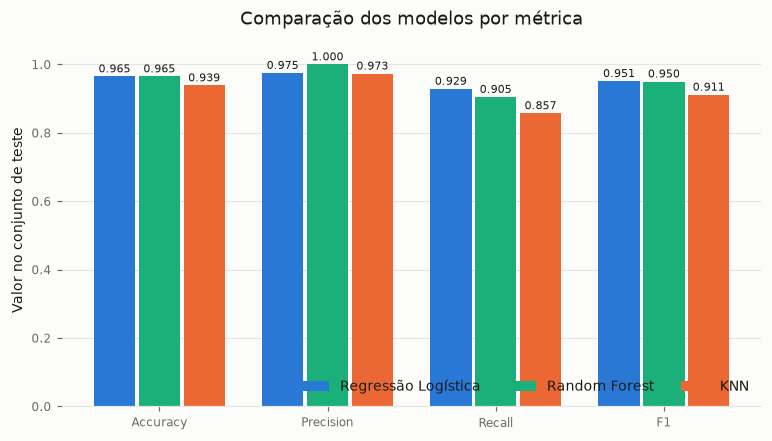

In [5]:
resultados_teste = evaluation.evaluate_all(modelos_ajustados, X_test, y_test)
display(resultados_teste)
evaluation.plot_metrics_comparison(resultados_teste);

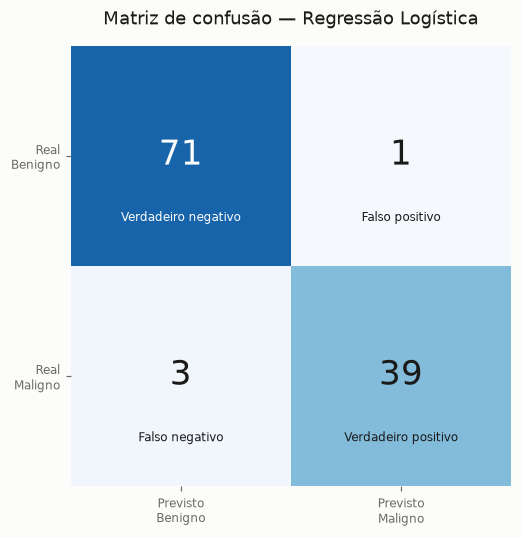

In [6]:
modelo_final = modelos_ajustados[melhor_modelo]
evaluation.plot_confusion_matrix(modelo_final, X_test, y_test, melhor_modelo);

**Discussão.** No conjunto de teste, a regressão logística acerta 110 dos 114 casos:

- **71 verdadeiros negativos** — tumores benignos corretamente identificados
- **39 verdadeiros positivos** — tumores malignos corretamente identificados
- **1 falso positivo** — uma paciente encaminhada a exames adicionais desnecessários
- **3 falsos negativos** — **três tumores malignos classificados como benignos**

Os três falsos negativos são o número que importa. Com recall de 0,929, o modelo deixa passar
aproximadamente 1 em cada 14 tumores malignos. Isso é bom para um sistema de apoio, mas
**inaceitável para decisão autônoma** — e é exatamente por isso que o médico dá a palavra final.

A Random Forest tem precisão perfeita (1,000, nenhum falso positivo) mas 4 falsos negativos. Trocar
um falso positivo por um falso negativo é um péssimo negócio neste contexto: o primeiro custa um
exame, o segundo custa um diagnóstico perdido.

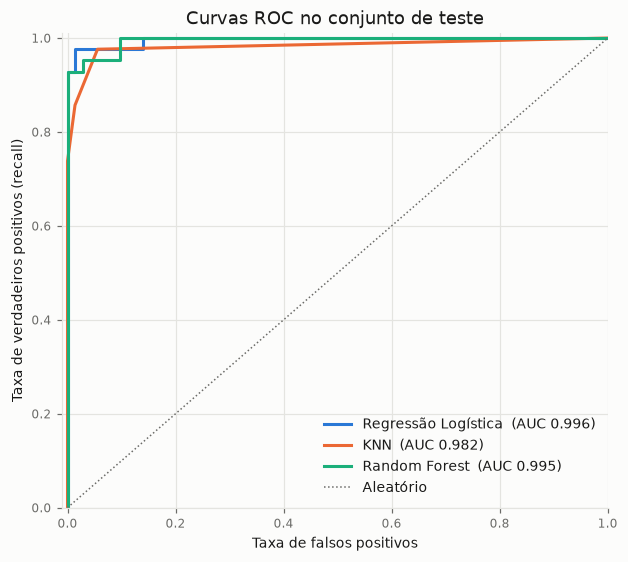

In [7]:
evaluation.plot_roc_curves(modelos_ajustados, X_test, y_test);

**Discussão.** As três curvas ficam muito próximas do canto superior esquerdo, com AUC entre 0,983 e
0,996. A AUC mede a capacidade de ordenar corretamente os casos por risco, independentemente do
limiar escolhido — e a regressão logística lidera também aqui (0,996).

AUC alta com recall de 0,929 no limiar padrão significa uma coisa importante: **o modelo separa bem,
o que está mal calibrado é o corte**. É o que a próxima seção explora.

---
## 6. Ajuste do limiar de decisão

O limiar padrão de 0,5 não tem nada de especial — é apenas a convenção do `predict()`. Em um
contexto clínico, faz sentido escolher o corte pela consequência do erro.

,limiar,recall,precisao,f1,falsos_negativos,falsos_positivos
0,0.2,0.9762,0.9111,0.9425,1,4
1,0.3,0.9762,0.9762,0.9762,1,1
2,0.4,0.9524,0.9756,0.9639,2,1
3,0.5,0.9286,0.9750,0.9512,3,1
4,0.6,0.9048,1.0000,0.9500,4,0
5,0.7,0.9048,1.0000,0.9500,4,0


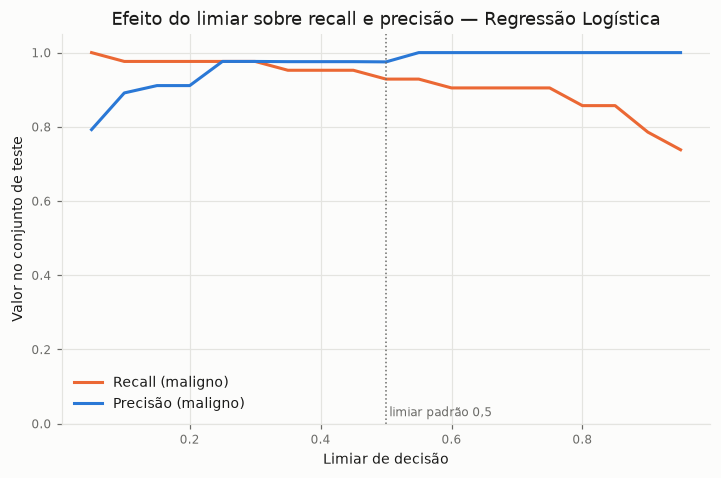

In [8]:
limiares = evaluation.threshold_analysis(modelo_final, X_test, y_test)
display(limiares)
evaluation.plot_threshold_tradeoff(modelo_final, X_test, y_test, melhor_modelo);

**Discussão — o resultado mais relevante deste notebook.** Baixar o limiar de 0,50 para **0,30**
melhora *todas* as métricas ao mesmo tempo:

| Limiar | Recall | Precisão | F1 | Falsos negativos | Falsos positivos |
|---|---|---|---|---|---|
| 0,50 (padrão) | 0,929 | 0,975 | 0,951 | 3 | 1 |
| **0,30** | **0,976** | **0,976** | **0,976** | **1** | 1 |

Os falsos negativos caem de 3 para 1 sem nenhum aumento de falsos positivos. Em termos clínicos:
duas pacientes a mais com tumor maligno seriam corretamente sinalizadas, sem custo adicional de
exames desnecessários.

Duas ressalvas honestas sobre esse número:

1. **O conjunto de teste tem 114 casos.** Uma diferença de dois falsos negativos é estatisticamente
   frágil — pode não se repetir em outra amostra. O limiar ideal deveria ser calibrado por validação
   cruzada no treino, e não escolhido olhando o teste, sob risco de estar ajustando ao próprio
   conjunto de avaliação.
2. **A direção do ajuste, porém, é defensável independentemente do valor exato.** Como o custo de um
   falso negativo é muito maior que o de um falso positivo, um limiar abaixo de 0,5 é a escolha
   racional para triagem, mesmo que o valor ótimo preciso varie.

---
## 7. Explicabilidade

O modelo acerta 96,5% dos casos — mas *por quê*? Um sistema de apoio ao diagnóstico que não explica
sua previsão não é utilizável na prática: o médico precisa poder concordar ou discordar com base no
raciocínio, não apenas no número.

Três técnicas complementares, da mais específica para a mais geral:

| Técnica | O que responde | Limitação |
|---|---|---|
| **Coeficientes** | direção e força de cada medida no modelo linear | sofre com a multicolinearidade; só vale para modelos lineares |
| **Importância por permutação** | quanto o desempenho piora sem aquela medida | agnóstica ao modelo, mas apenas global |
| **SHAP** | quanto cada medida contribuiu para *esta* paciente | custo computacional maior |

,feature,coeficiente,razao_de_chances
0,texture_worst,1.4341,4.196
1,radius_se,1.2333,3.433
2,symmetry_worst,1.0613,2.890
3,concave points_mean,0.9528,2.593
4,concavity_worst,0.9114,2.488
5,area_se,0.9090,2.482
6,compactness_se,-0.9069,0.404
7,area_worst,0.9005,2.461
8,radius_worst,0.8970,2.452
9,concavity_mean,0.7823,2.186


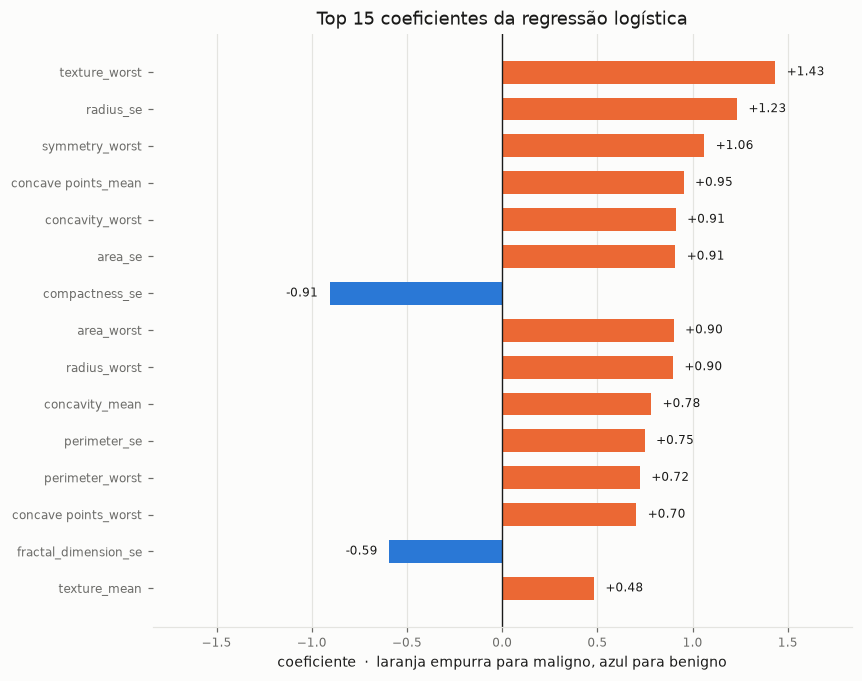

In [9]:
from src import explain

coeficientes = explain.linear_coefficients(modelo_final, list(X.columns))
display(coeficientes.head(10))
explain.plot_coefficients(coeficientes);

**Discussão — e uma surpresa.** O maior coeficiente é `texture_worst` (+1,43), não `concave
points_worst`, que liderava tanto o *d* de Cohen quanto a correlação com o alvo. Como explicar?

**Multicolinearidade.** Como visto na seção de correlação, `concave points_worst` é altamente
correlacionada com várias outras medidas de tamanho e contorno. A regularização L2 distribui o peso
entre todas elas, então nenhuma isoladamente recebe um coeficiente grande. Já `texture_worst` é
relativamente independente das demais — carrega informação que nenhuma outra feature fornece, e por
isso recebe peso alto.

Isso ilustra uma armadilha real de interpretação: **coeficiente alto significa "informação única
e útil", não "medida mais importante clinicamente"**. É por isso que os coeficientes sozinhos não
bastam.

Como as features estão padronizadas, os coeficientes são comparáveis entre si e a razão de chances
tem leitura direta: um aumento de um desvio padrão em `texture_worst` multiplica por ~4,2 a chance
de o tumor ser maligno, mantidas as demais medidas constantes.

,feature,queda_media,desvio
0,texture_worst,0.0540,0.0212
1,concavity_worst,0.0421,0.0243
2,symmetry_worst,0.0278,0.0185
3,concave points_worst,0.0262,0.0188
4,radius_worst,0.0040,0.0205
5,concave points_mean,0.0024,0.0198
6,area_worst,0.0024,0.0188
7,smoothness_worst,0.0024,0.0128
8,perimeter_worst,0.0016,0.0194
9,radius_mean,0.0008,0.0168


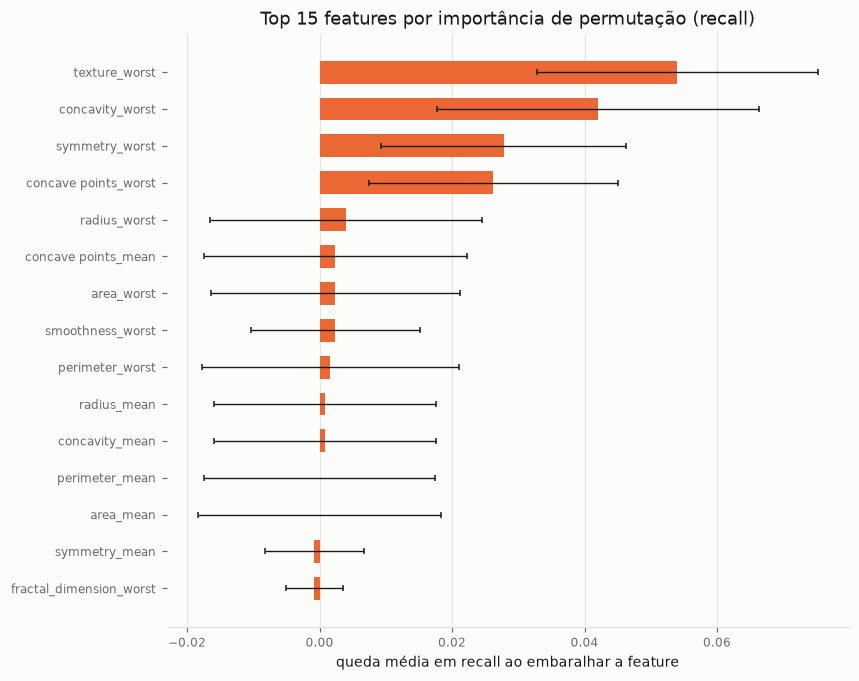

In [10]:
permutacao = explain.permutation_scores(modelo_final, X_test, y_test, scoring="recall")
display(permutacao.head(10))
explain.plot_permutation_importance(permutacao);

**Discussão.** A permutação mede o que importa na prática: embaralhar `texture_worst` derruba o
recall em 5,4 pontos percentuais; `concavity_worst`, em 4,2. Depois das quatro primeiras, a queda
cai a praticamente zero — sinal de que **o modelo se apoia em poucas medidas**, e as demais são
redundantes ou irrelevantes.

Note que a permutação foi medida em **recall**, a métrica prioritária, e não em acurácia. A escolha
importa: uma feature pode ser importante para a acurácia geral e irrelevante para detectar casos
malignos, que é o que interessa aqui.

O desvio padrão das barras é grande em relação à queda média — consequência dos 114 casos de teste.
Os rankings devem ser lidos como indicativos, não como uma ordem precisa.

C:\workspace\ML-breast-cancer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,shap_medio
0,texture_worst,1.2507
1,radius_se,0.7611
2,symmetry_worst,0.7406
3,concave points_mean,0.7228
4,radius_worst,0.7125
5,concavity_worst,0.6937
6,compactness_se,0.6887
7,area_worst,0.6846
8,concave points_worst,0.5749
9,perimeter_worst,0.5614


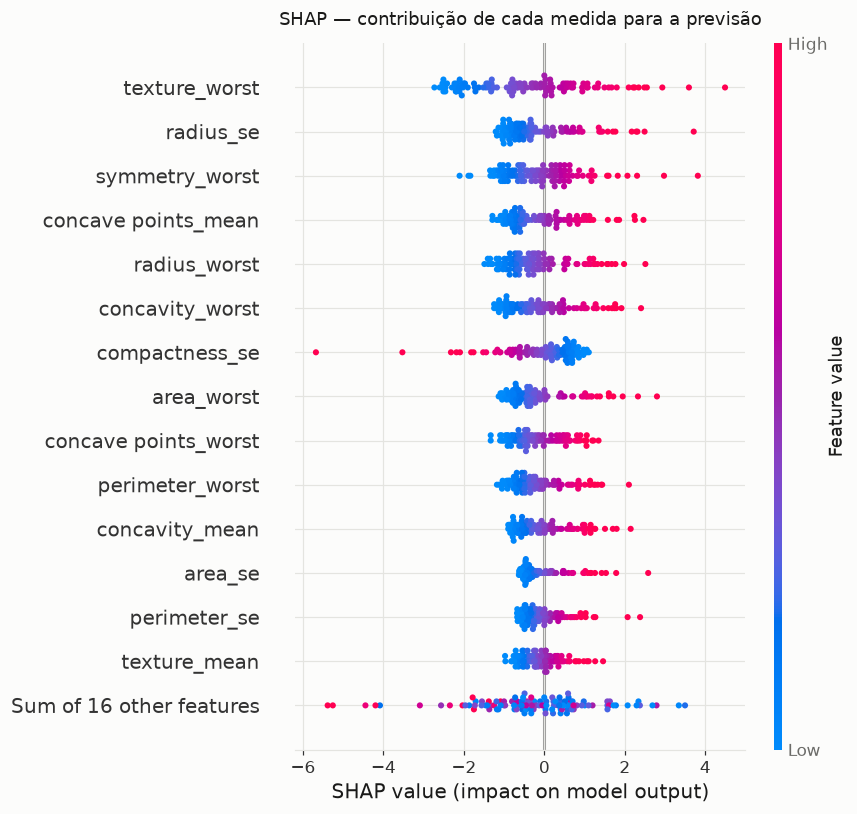

In [11]:
explicacao = explain.shap_explanation(modelo_final, X_train, X_test)
display(explain.shap_importance(explicacao).head(10))
explain.plot_shap_beeswarm(explicacao);

**Discussão.** No beeswarm, cada ponto é uma paciente. A posição horizontal mostra o quanto aquela
medida empurrou a previsão para maligno (direita) ou benigno (esquerda); a cor indica se o valor da
medida era alto (vermelho) ou baixo (azul).

O padrão é consistente e clinicamente coerente: para quase todas as features do topo,
**valores altos (vermelho) empurram para maligno**. Núcleos maiores, mais irregulares e com contorno
mais reentrante aumentam a probabilidade prevista de malignidade — exatamente o que a literatura
médica descreve.

A exceção é `compactness_se`, cujo padrão se inverte (valores altos empurram para benigno). É um
efeito de compensação estatística entre variáveis correlacionadas, não um achado clínico — o tipo
de resultado que exige cautela antes de virar afirmação médica.

Falsos negativos no teste (índices): [16, 87, 112]
Caso 16: diagnóstico real = maligno · probabilidade prevista = 0.061


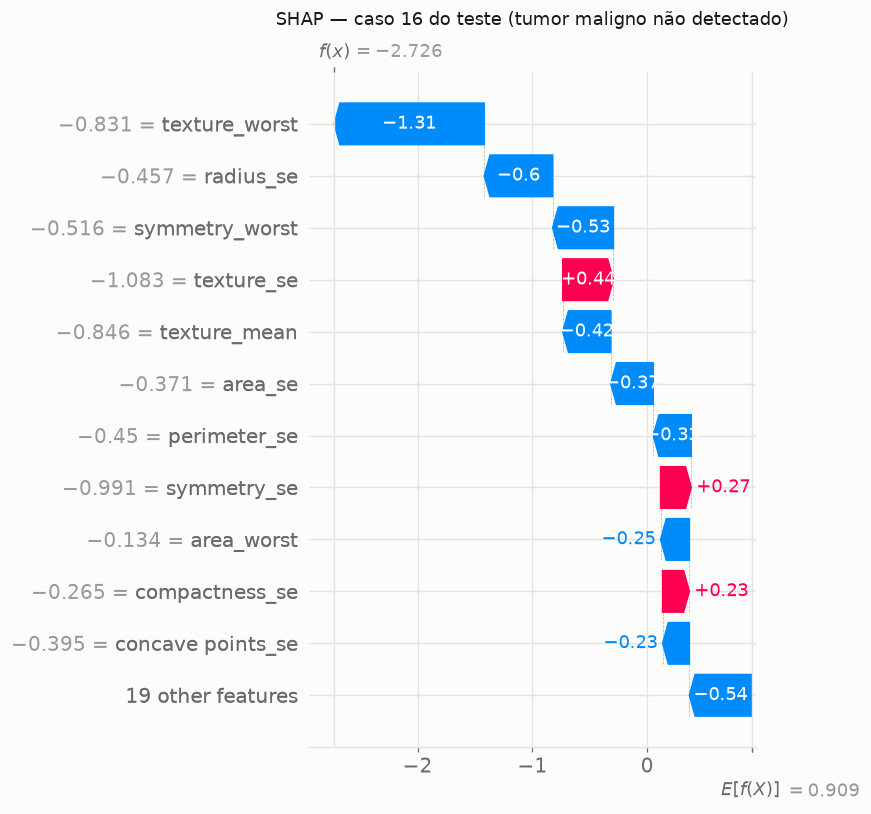

In [12]:
import numpy as np

previsoes = modelo_final.predict(X_test)
falsos_negativos = np.where((y_test.to_numpy() == 1) & (previsoes == 0))[0]
print(f"Falsos negativos no teste (índices): {falsos_negativos.tolist()}")

caso = int(falsos_negativos[0])
probabilidade = modelo_final.predict_proba(X_test)[caso, 1]
print(f"Caso {caso}: diagnóstico real = maligno · probabilidade prevista = {probabilidade:.3f}")

explain.plot_shap_waterfall(
    explicacao,
    caso,
    f"SHAP — caso {caso} do teste (tumor maligno não detectado)",
    "14_shap_caso_falso_negativo.png",
);

**Discussão — o caso mais instrutivo do projeto.** Este é um dos três tumores malignos que o modelo
classificou como benignos. O gráfico de cascata decompõe exatamente por que ele errou.

Praticamente **todas as medidas desta paciente estão abaixo da média** da base (em unidades de
desvio padrão): `texture_worst` a −0,83, `texture_mean` a −0,85, `symmetry_worst` a −0,52,
`area_worst` a −0,13. Cada uma dessas medidas empurrou a previsão para "benigno", e a soma levou a
saída do modelo bem para o lado negativo.

Em linguagem clínica: **é um tumor maligno cujos núcleos celulares têm morfologia pouco
característica**. O modelo não cometeu um erro aleatório — ele viu um caso que genuinamente se
parece com os benignos nas 30 medidas disponíveis.

Isso tem duas implicações diretas para o uso na prática:

1. **O modelo não substitui o médico.** Existem tumores malignos morfologicamente discretos, e
   nenhuma quantidade de ajuste de hiperparâmetro resolve isso — a informação necessária não está
   nas features.
2. **A explicação é acionável.** Um médico vendo esta cascata sabe que a previsão "benigno" se apoia
   em medidas fracas e sem nenhum sinal forte em contrário. Isso é qualitativamente diferente de um
   caso benigno com evidência robusta, e justifica exames complementares.

---
## Síntese da modelagem

| Item | Resultado |
|---|---|
| Modelo escolhido | Regressão Logística (`C = 1,0`) |
| Critério de escolha | maior F1 na validação cruzada de 5 folds no treino |
| Acurácia no teste | 0,965 |
| Recall no teste (maligno) | 0,929 |
| F1 no teste | 0,951 |
| AUC no teste | 0,996 |
| Falsos negativos | 3 em 42 casos malignos |
| Com limiar 0,30 | recall 0,976 · 1 falso negativo |

**Próximo passo:** o modelo acerta — mas *por quê*? Um sistema de apoio ao diagnóstico que não
explica sua previsão não é utilizável na prática clínica. A explicabilidade é o tema da Fase 5:
coeficientes, importância por permutação e SHAP.